### Escuela Politécnica Nacional
$$ Deber8 $$
nombre: Lady Velasquez


## 1. Dados los datos:

| $x_i$ | 4.0 | 4.2 | 4.5 | 4.7 | 5.1 | 5.5 | 5.9 | 6.3 | 6.8 | 7.1 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **$y_i$** | 102.56 | 130.11 | 113.18 | 142.05 | 167.53 | 195.14 | 224.87 | 256.73 | 299.50 | 326.72 |

**Instrucciones:**
* **a.** Construya el polinomio por mínimos cuadrados de grado 1 y calcule el error.
* **b.** Construya el polinomio por mínimos cuadrados de grado 2 y calcule el error.
* **c.** Construya el polinomio por mínimos cuadrados de grado 3 y calcule el error.
* **d.** Construya el polinomio por mínimos cuadrados de la forma $be^{ax}$ y calcule el error.
* **e.** Construya el polinomio por mínimos cuadrados de la forma $bx^a$ y calcule el error.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def resolver_minimos_cuadrados(x, y, titulo="Ajuste de Datos"):
    x = np.array(x)
    y = np.array(y)
    x_smooth = np.linspace(x.min(), x.max(), 100)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='black', label='Datos Originales', zorder=5)
    
    modelos = {}
    
    # a, b, c
    for grado in [1, 2, 3]:
        coefs = np.polyfit(x, y, grado)
        y_pred = np.polyval(coefs, x)
        error = np.sum((y - y_pred)**2)
        modelos[f'Grado {grado}'] = (coefs, error)
        plt.plot(x_smooth, np.polyval(coefs, x_smooth), label=f'Grado {grado} (Err: {error:.2f})')

    # d
    params_exp = np.polyfit(x, np.log(y), 1)
    a_exp, b_exp = params_exp[0], np.exp(params_exp[1])
    y_pred_exp = b_exp * np.exp(a_exp * x)
    err_exp = np.sum((y - y_pred_exp)**2)
    modelos['Exponencial'] = ((a_exp, b_exp), err_exp)
    plt.plot(x_smooth, b_exp * np.exp(a_exp * x_smooth), '--', label=f'Exp b*e^ax (Err: {err_exp:.2f})')

    # e
    params_pow = np.polyfit(np.log(x), np.log(y), 1)
    a_pow, b_pow = params_pow[0], np.exp(params_pow[1])
    y_pred_pow = b_pow * (x**a_pow)
    err_pow = np.sum((y - y_pred_pow)**2)
    modelos['Potencia'] = ((a_pow, b_pow), err_pow)
    plt.plot(x_smooth, b_pow * (x_smooth**a_pow), ':', label=f'Potencia b*x^a (Err: {err_pow:.2f})')

    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()

    for nombre, data in modelos.items():
        print(f"--- {nombre} ---")
        print(f"Parámetros/Coefs: {data[0]}")
        print(f"Error (SSE): {data[1]:.6f}\n")


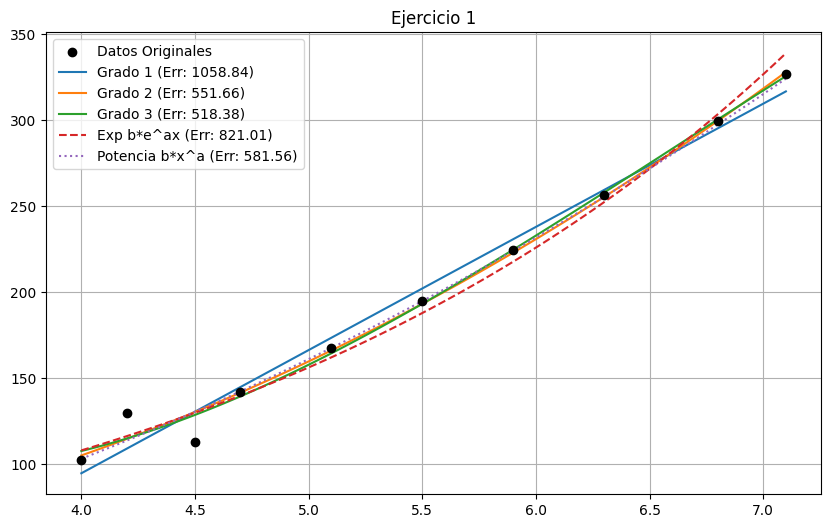

--- Grado 1 ---
Parámetros/Coefs: [  71.61024372 -191.57241853]
Error (SSE): 1058.838886

--- Grado 2 ---
Parámetros/Coefs: [  8.21707232 -19.30860379  51.00078939]
Error (SSE): 551.656200

--- Grado 3 ---
Parámetros/Coefs: [  -2.60683872   51.56095694 -254.87478338  469.16326528]
Error (SSE): 518.383065

--- Exponencial ---
Parámetros/Coefs: (np.float64(0.36847662383170726), np.float64(24.77672369783612))
Error (SSE): 821.005109

--- Potencia ---
Parámetros/Coefs: (np.float64(1.9932845789479021), np.float64(6.518682345785463))
Error (SSE): 581.557273



In [ ]:
x1 = [4.0, 4.2, 4.5, 4.7, 5.1, 5.5, 5.9, 6.3, 6.8, 7.1]
y1 = [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72]
resolver_minimos_cuadrados(x1, y1, "Ejercicio 1")


## 2. Repita el ejercicio anterior para los siguientes datos:

| $x_i$ | 0.2 | 0.3 | 0.6 | 0.9 | 1.1 | 1.3 | 1.4 | 1.6 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **$y_i$** | 0.050446 | 0.098426 | 0.33277 | 0.72660 | 1.0972 | 1.5697 | 1.8487 | 2.5015 |


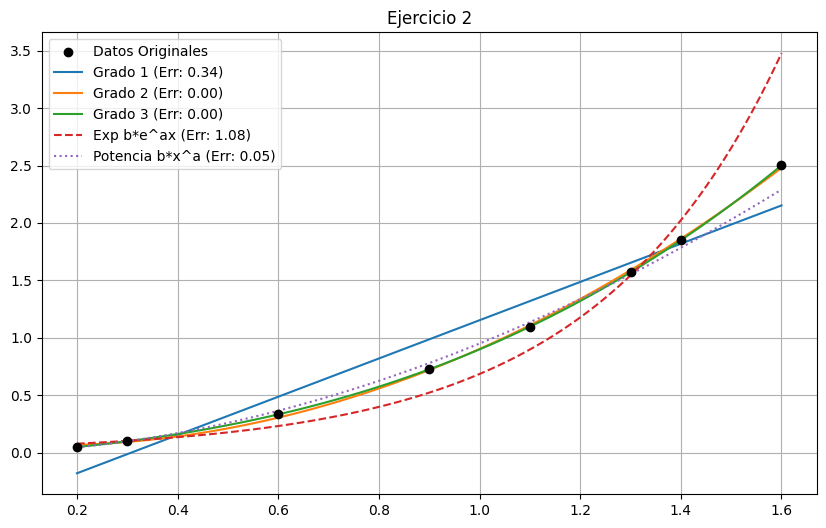

--- Grado 1 ---
Parámetros/Coefs: [ 1.66554008 -0.51245682]
Error (SSE): 0.335590

--- Grado 2 ---
Parámetros/Coefs: [ 1.12942387 -0.31140346  0.08514393]
Error (SSE): 0.002420

--- Grado 3 ---
Parámetros/Coefs: [ 0.2662081   0.40293221  0.24838578 -0.0184014 ]
Error (SSE): 0.000005

--- Exponencial ---
Parámetros/Coefs: (np.float64(2.707294686913418), np.float64(0.04570748069533022))
Error (SSE): 1.075049

--- Potencia ---
Parámetros/Coefs: (np.float64(1.872009284326521), np.float64(0.9501564755920616))
Error (SSE): 0.054477



In [6]:
x2 = [0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6]
y2 = [0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015]
resolver_minimos_cuadrados(x2, y2, "Ejercicio 2")

3. La siguiente tabla muestra los promedios de puntos del colegio de 20 especialistas en matemáticas y ciencias computacionales, junto con las calificaciones que recibieron estos estudiantes en la parte de matemáticas de la prueba ACT mientras estaban en secundaria.

| Puntuación ACT | Promedio de puntos | Puntuación ACT | Promedio de puntos |
| :--- | :--- | :--- | :--- |
| 28 | 3.84 | 29 | 3.75 |
| 25 | 3.21 | 28 | 3.65 |
| 28 | 3.23 | 27 | 3.87 |
| 27 | 3.63 | 29 | 3.75 |
| 28 | 3.75 | 21 | 1.66 |
| 33 | 3.20 | 28 | 3.12 |
| 28 | 3.41 | 28 | 2.96 |
| 29 | 3.38 | 26 | 2.92 |
| 23 | 3.53 | 30 | 3.10 |
| 27 | 2.03 | 24 | 2.81 |

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def solve_linear_regression(x, y, title, x_label, y_label):
    x, y = np.array(x), np.array(y)
    m, b = np.polyfit(x, y, 1)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='red', label='Datos')
    plt.plot(x, m*x + b, color='blue', label=f'Ajuste: y = {m:.4f}x + {b:.4f}')
    
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"--- {title} ---")
    print(f"Ecuación: y = {m:.6f}x + {b:.6f}")
    print(f"Pendiente (m): {m:.6f}")
    print(f"Intersección (b): {b:.6f}\n")


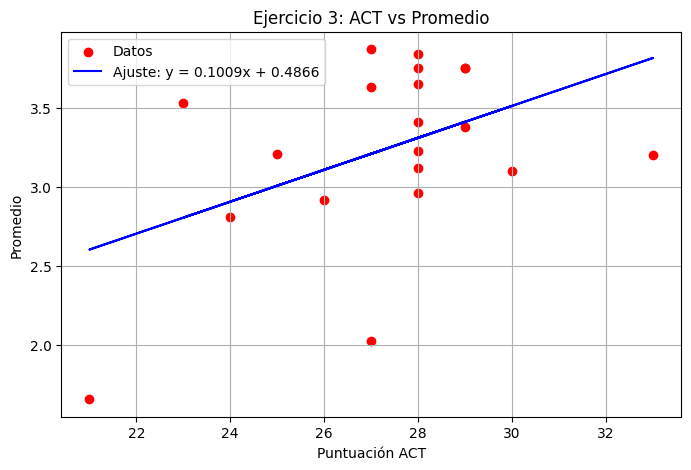

--- Ejercicio 3: ACT vs Promedio ---
Ecuación: y = 0.100858x + 0.486576
Pendiente (m): 0.100858
Intersección (b): 0.486576



In [9]:
act_scores = [28, 25, 28, 27, 28, 33, 28, 29, 23, 27, 29, 28, 27, 29, 21, 28, 28, 26, 30, 24]
gpa_scores = [3.84, 3.21, 3.23, 3.63, 3.75, 3.20, 3.41, 3.38, 3.53, 2.03, 3.75, 3.65, 3.87, 3.75, 1.66, 3.12, 2.96, 2.92, 3.10, 2.81]



solve_linear_regression(act_scores, gpa_scores, "Ejercicio 3: ACT vs Promedio", "Puntuación ACT", "Promedio")


4. El siguiente conjunto de datos, presentado al Subcomité Antimonopolio del Senado, muestra las
características comparativas de supervivencia durante un choque de automóviles de diferentes clases.
Encuentre la recta por mínimos cuadrados que aproxima estos datos (la tabla muestra el porcentaje de
vehículos que participaron en un accidente en los que la lesión más grave fue fatal o seria).

| Tipo | Peso promedio | Porcentaje de presentación |
| :--- | :--- | :--- |
| 1. Regular lujoso doméstico | 4800 lb | 3.1 |
| 2. Regular intermediario doméstico | 3700 lb | 4.0 |
| 3. Regular económico doméstico | 3400 lb | 5.2 |
| 4. Compacto doméstico | 2800 lb | 6.4 |
| 5. Compacto extranjero | 1900 lb | 9.6 |

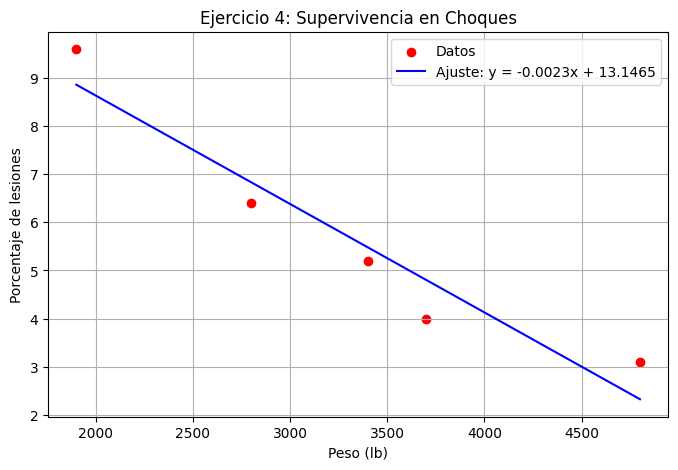

--- Ejercicio 4: Supervivencia en Choques ---
Ecuación: y = -0.002255x + 13.146500
Pendiente (m): -0.002255
Intersección (b): 13.146500



In [10]:
pesos = [4800, 3700, 3400, 2800, 1900]
porcentajes = [3.1, 4.0, 5.2, 6.4, 9.6]

solve_linear_regression(pesos, porcentajes, "Ejercicio 4: Supervivencia en Choques", "Peso (lb)", "Porcentaje de lesiones")